In [40]:
#!pip install ydata_profiling

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [42]:
#IBM HR dataset id = 43696
hr_data = fetch_openml(data_id=43696, as_frame = True)

In [43]:
df = hr_data.frame

In [44]:
df.shape

(1470, 35)

In [45]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,'Life Sciences',1,1,2,Female,94,3,2,'Sales Executive',4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,'Research Development',8,1,'Life Sciences',1,2,3,Male,61,2,2,'Research Scientist',2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,'Research Development',2,2,Other,1,4,4,Male,92,2,1,'Laboratory Technician',3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,'Research Development',3,4,'Life Sciences',1,5,4,Female,56,3,1,'Research Scientist',3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,'Research Development',2,1,Medical,1,7,1,Male,40,3,1,'Laboratory Technician',2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [46]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [48]:
from ydata_profiling import ProfileReport

In [49]:
profile = ProfileReport(df, title = "HR Employee Attrition - Auto EDA Report", explorative = True)

In [50]:
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [52]:
# Separate feature(x) and target(y)
y = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0) #Yes = 1 and No = 0
x = df.drop(['Attrition'], axis = 1)

In [53]:
#Dropping unnecessarry columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
x = x.drop(columns = [col for col in cols_to_drop if col in x.columns], errors = 'ignore')

In [54]:
# Using One Hot Encoding to convert categorical values to numerical value
x = pd.get_dummies(x, drop_first = True)

In [55]:
# Spliting Train Test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [56]:
# Using max_depth for prevent overfitting
model = DecisionTreeClassifier(random_state = 42, max_depth = 5)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [57]:
predictions = model.predict(x_test)

In [58]:
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8231292517006803


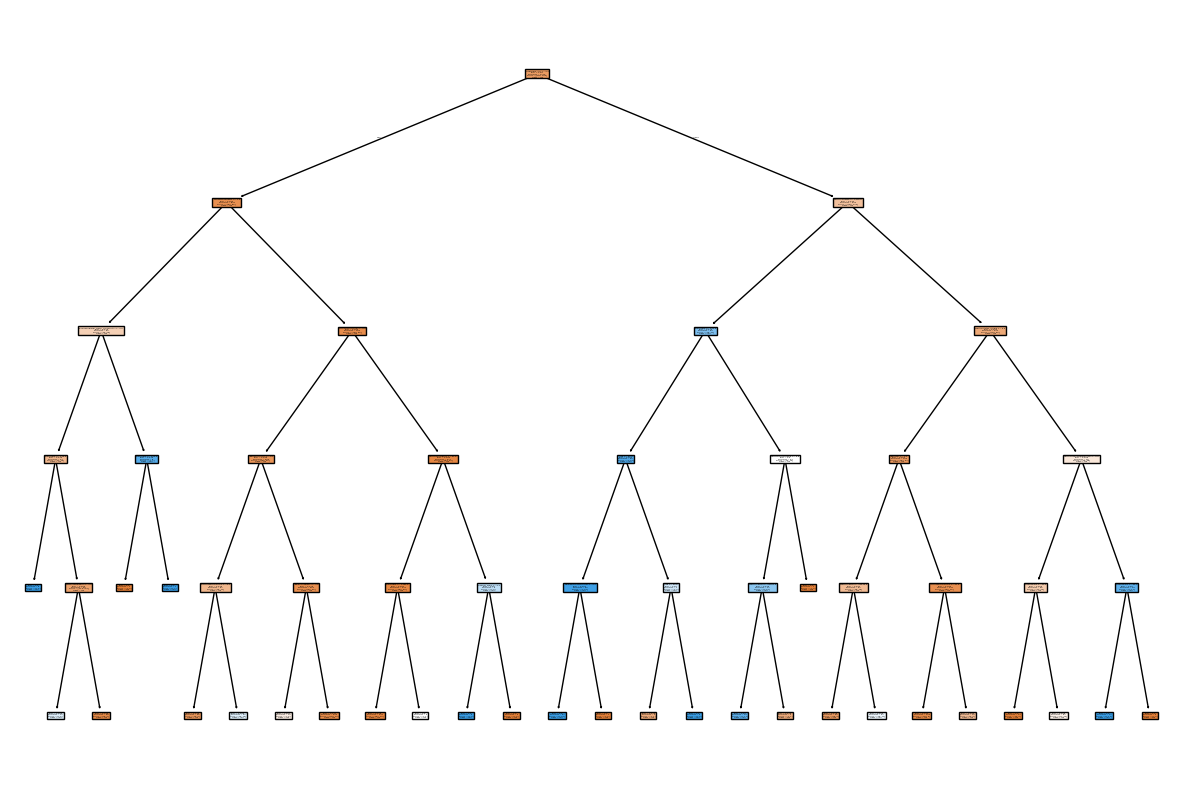

In [59]:
from sklearn.tree import plot_tree

plt.figure(figsize = (15, 10))
plot_tree(model, feature_names = x.columns, class_names = ['No', 'Yes'], filled = True)
plt.show()

In [60]:
importance = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': x.columns, 'Importance': importance})

In [61]:
top_10_features = feature_importance_df.sort_values(by = 'Importance', ascending = False).head(10)

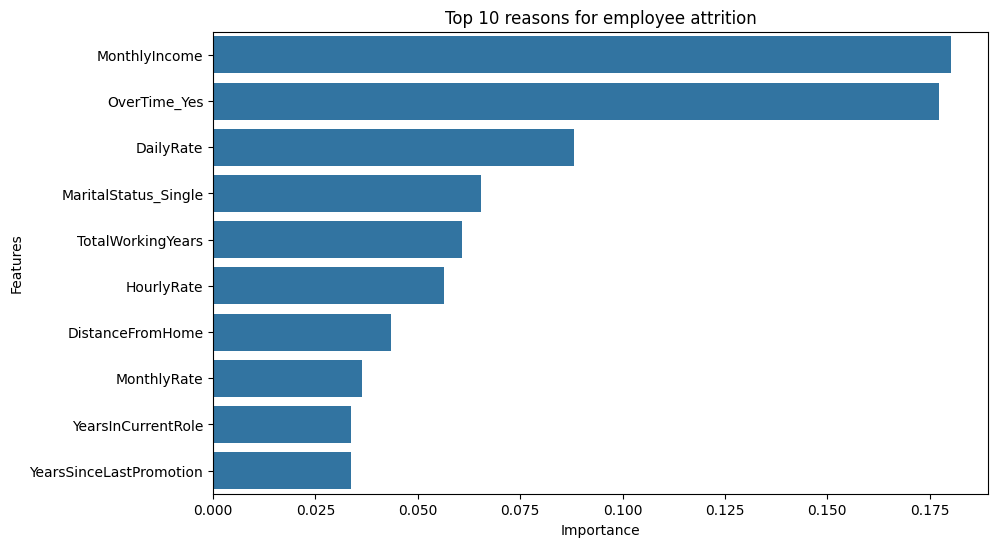

In [62]:
plt.figure(figsize = (10, 6))
sns.barplot(x = 'Importance', y = 'Feature', data = top_10_features)
plt.title('Top 10 reasons for employee attrition')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [63]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_test, predictions)

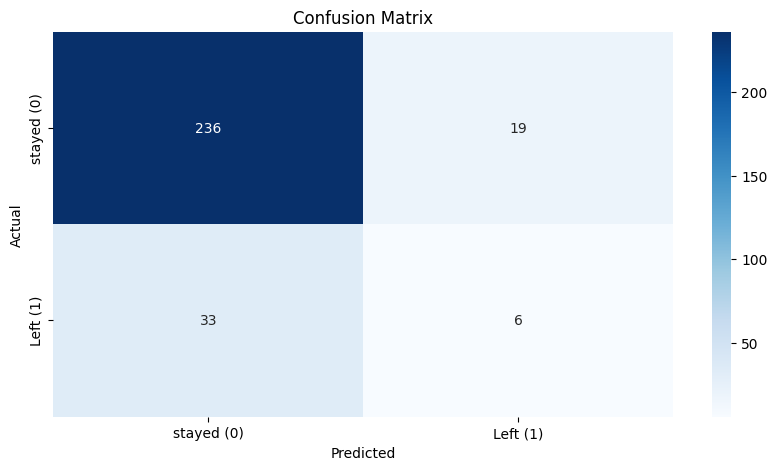

In [64]:
plt.figure(figsize = (10, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['stayed (0)', 'Left (1)'],
            yticklabels = ['stayed (0)', 'Left (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [65]:
print("Classification Report:\n")
print(classification_report(y_test, predictions, target_names=['Stayed', 'Left']))

Classification Report:

              precision    recall  f1-score   support

      Stayed       0.88      0.93      0.90       255
        Left       0.24      0.15      0.19        39

    accuracy                           0.82       294
   macro avg       0.56      0.54      0.54       294
weighted avg       0.79      0.82      0.81       294



In [66]:
# Creating new model by class_weight='balanced'
model_balanced = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')

In [69]:
# Train model
model_balanced.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [71]:
# New prediction
predictions_balanced = model_balanced.predict(x_test)

In [72]:
print("--- Results using class_weight='balanced' ---\n")
print(classification_report(y_test, predictions_balanced, target_names=['Stayed', 'Left']))

--- Results using class_weight='balanced' ---

              precision    recall  f1-score   support

      Stayed       0.90      0.83      0.86       255
        Left       0.27      0.41      0.32        39

    accuracy                           0.77       294
   macro avg       0.58      0.62      0.59       294
weighted avg       0.82      0.77      0.79       294

